In [2]:
import torch
import matplotlib.pyplot as plt

In [47]:
# use integer values in uint8 (0-255) and convert to float before taking mean
box = torch.randint(0, 256, size=(3, 256, 256))

print(box.max(),box.min())
box = (box- box.min())/box.max()-box.min()

box.mean(),box.std()

tensor(255) tensor(0)


(tensor(0.4994), tensor(0.2895))

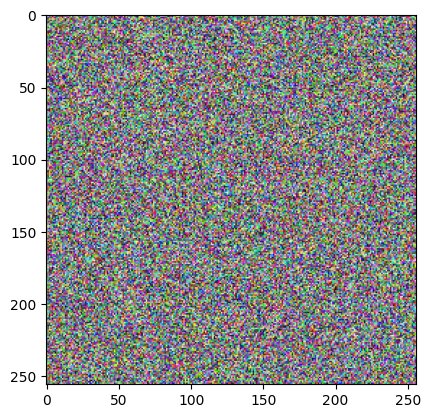

In [48]:
plt.imshow(box.transpose(0,2))

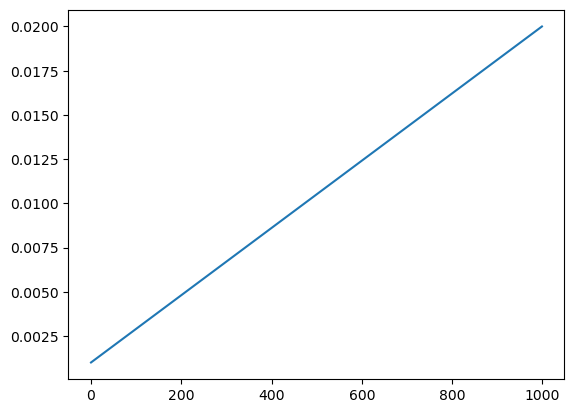

In [2]:
plt.plot(torch.linspace(0.001,0.02,1000))

torch.Size([1000, 1024])
torch.Size([1000, 1024])


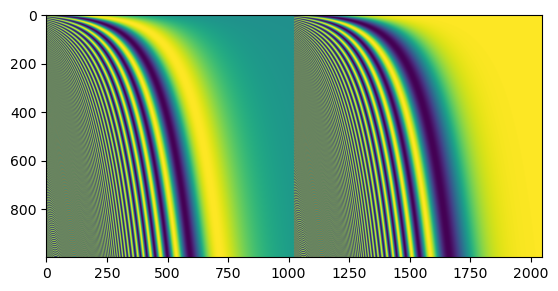

In [39]:

pos = torch.arange(1000) # B dim t   
dim = 2048

factor = 10000 ** (2 * torch.arange(start=0, end=dim//2) / dim)

pos_embd = pos[:,None] / factor

final_embd = torch.cat((pos_embd.sin(), pos_embd.cos()), dim=-1)

print(pos_embd.shape)
print(torch.arange(0,dim//2)[None,:].repeat(pos_embd.shape[0],1).shape)
plt.imshow(final_embd.detach().numpy())
plt.show()

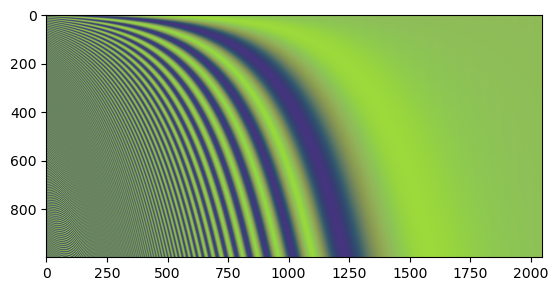

In [40]:
def get_time_embedding(time_steps, dim):

    half_dim = dim // 2

    factor = 10000 ** (
        torch.arange(half_dim, device=time_steps.device) / half_dim
    )

    emb = time_steps[:, None] / factor

    emb = torch.stack((torch.sin(emb), torch.cos(emb)), dim=-1)

    emb = emb.view(time_steps.shape[0], dim)

    return emb


plt.imshow(get_time_embedding(torch.arange(1000), 2048).detach().numpy())